In [1]:
import numpy as np
from zfish._io import import16chFlt
from zfish.utils import *
from zfish.openfield import *
from zfish.local_path import *

code_id = "OF 2D Translation"
loc = os.path.join(figpath, code_id)
os.makedirs(loc, exist_ok=True)

In [2]:
path = r"D:\EnData\Open Field\10231\S2 OF\res.16chFlt"
res = import16chFlt(path, nchannel=28)

fish = 10231
loc_fish = os.path.join(loc, str(fish))
os.makedirs(loc_fish, exist_ok=True)

Processing trials: 100%|██████████| 110/110 [00:01<00:00, 70.11it/s]


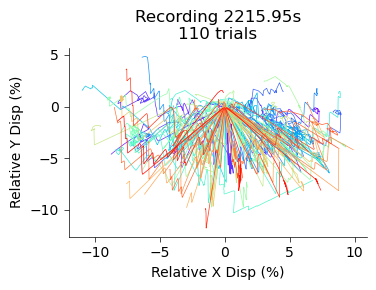

Time: (13175600,)
Dist: (13175600,)
x: (13175600,)
y: (13175600,)
Trial: (13175600,)
Power Diff: (13175600,)
Displacement Angle: (13175600,)


Binning trials: 100%|██████████| 110/110 [00:07<00:00, 14.30it/s]


In [3]:
n_disp = res['n_displacements']
idx = np.where((n_disp[1:] >= 1) &(np.diff(n_disp) == 1))[0] + 1
beg = idx
end = np.append(idx[1:], len(n_disp))

ch0 = np.convolve(res['fltCh0'], np.ones(200), mode='same') / np.convolve(np.ones_like(res['fltCh0']), np.ones(200), mode='same')
ch1 = np.convolve(res['fltCh1'], np.ones(200), mode='same') / np.convolve(np.ones_like(res['fltCh1']), np.ones(200), mode='same')

def coordinate_orient(x: np.ndarray, y: np.ndarray, angle: float):
    alpha = np.arctan2(y, x)
    radial = np.sqrt(x**2 + y**2)
    theta = (reorient(alpha) - angle) % (2 * np.pi)
    alpha_converted = reorient(theta)
    x_converted = np.cos(alpha_converted) * radial
    y_converted = np.sin(alpha_converted) * radial
    return x_converted, y_converted

import numpy as np

def signed_angle(v1, v2):
    v1 = np.asarray(v1, dtype=float)
    v2 = np.asarray(v2, dtype=float)

    if np.linalg.norm(v1) == 0 or np.linalg.norm(v2) == 0:
        raise ValueError("The angle is undefined for a zero vector.")

    dot = v1[0] * v2[0] + v1[1] * v2[1]
    cross = v1[0] * v2[1] - v1[1] * v2[0]

    angle_rad = np.arctan2(cross, dot)

    return angle_rad

TrialData = {
    "Time": [],
    "Dist": [],
    "x": [],
    "y": [],
    "Trial": [],
    "Power Diff": [],
    "Displacement Angle": [],
    
}
fig = plt.figure(figsize=(4, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
colors = sns.color_palette("rainbow", len(beg))
for i in tqdm(range(len(beg)), desc="Processing trials"):
    x, y = coordinate_orient(res['behav_pos_x'][beg[i]-1:end[i]] - 50, res['behav_pos_y'][beg[i]-1:end[i]] - 50, res['behav_orient'][beg[i]-1])
    ax.plot(x[1:30000]-x[0], y[1:30000] - y[0], color=colors[i], lw=0.5)
    TrialData["Time"].append(res['behav_time'][beg[i]:end[i]] - res['behav_time'][beg[i]])
    dist = np.sqrt((x[1:] - x[0])**2 + (y[1:] - y[0])**2)
    TrialData["Dist"].append(dist)
    TrialData["x"].append(x[1:])
    TrialData["y"].append(y[1:])
    TrialData["Trial"].append(np.full_like(x[1:], i))  # Store trial index for each time point
    TrialData["Power Diff"].append(ch0[beg[i]:end[i]] - ch1[beg[i]:end[i]])
    
    theta_re = reorient(res['behav_orient'][beg[i]])
    v1 = np.array([np.cos(theta_re), np.sin(theta_re)])
    v2 = np.array([res['displacementX'][beg[i]], res['displacementY'][beg[i]]])
    alpha_disp = signed_angle(v1, v2)
    TrialData["Displacement Angle"].append(np.full_like(x[1:], alpha_disp))  # Store trial index for each time point

ax.set_title(f"Recording {res['behav_time'][-1]:.2f}s\n{len(beg)} trials")
ax.set_ylabel("Relative Y Disp (%)")
ax.set_xlabel("Relative X Disp (%)")
plt.tight_layout()
plt.savefig(join(loc_fish, "Fish Trajectory By Trials.png"), dpi=600)
plt.savefig(join(loc_fish, "Fish Trajectory By Trials.svg"), dpi=300)
plt.show()

for key in TrialData.keys():
    TrialData[key] = np.concatenate(TrialData[key])
    print(f"{key}: {TrialData[key].shape}")
    
TrialBinnedData = {
    "Time": [],
    "Dist": [],
    "Trial": [],
    "Power Diff": [],
    "Displacement Angle": [],
}
TrialData['Time'] = (TrialData['Time'] // 0.05)*0.05
time_binned = np.linspace(0, 20, 401)[:-1]
for i in tqdm(np.unique(TrialData["Trial"]), desc="Binning trials"):
    idx = np.where(TrialData["Trial"] == i)[0]
    
    t = TrialData["Time"][idx]
    ds = TrialData["Dist"][idx]
    sp = TrialData['Power Diff'][idx]
    alpha_disp = TrialData['Displacement Angle'][idx]
    
    for j in range(len(time_binned)):
        mask = np.where((t >= time_binned[j]-1e-3) & (t < time_binned[j]+1e-3))[0]
        if np.any(mask):
            TrialBinnedData["Time"].append(time_binned[j])
            TrialBinnedData["Trial"].append(i)
            TrialBinnedData["Dist"].append(np.mean(ds[mask]))
            TrialBinnedData["Power Diff"].append(np.mean(sp[mask]))
            TrialBinnedData["Displacement Angle"].append(np.mean(alpha_disp[mask]))
            
for key in TrialBinnedData.keys():
    TrialBinnedData[key] = np.array(TrialBinnedData[key])

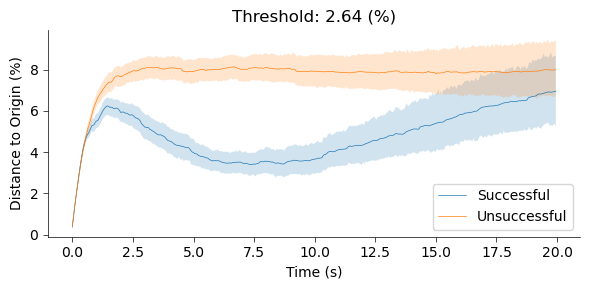

In [11]:
chance_idx = np.random.choice(res['behav_pos_x'].shape[0], size=10000, replace=True)
chance_next = np.random.choice(res['behav_pos_x'].shape[0], size=10000, replace=True)
chance_x = res['behav_pos_x'][chance_next] - res['behav_pos_x'][chance_idx]
chance_y = res['behav_pos_y'][chance_next] - res['behav_pos_y'][chance_idx]
chance_dist = np.sqrt(chance_x**2 + chance_y**2)

TrialBinnedData['Trial Block'] = TrialBinnedData['Trial'] // 20
TrialBinnedData['Trial Type'] = []
threshold = np.percentile(chance_dist, 5)
for i in np.unique(TrialBinnedData['Trial']):
    mask = np.where((TrialBinnedData['Trial'] == i)&(TrialBinnedData['Time'] >= 1))[0]
    if np.where(TrialBinnedData['Dist'][mask] < threshold)[0].size > 0:
        TrialBinnedData['Trial Type'].append(np.repeat("Successful", np.where(TrialBinnedData['Trial'] == i)[0].size))
    else:
        TrialBinnedData['Trial Type'].append(np.repeat("Unsuccessful", np.where(TrialBinnedData['Trial'] == i)[0].size))
TrialBinnedData['Trial Type'] = np.concatenate(TrialBinnedData['Trial Type'])

fig = plt.figure(figsize=(6, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x=TrialBinnedData["Time"],
    y=TrialBinnedData["Dist"],
    hue=TrialBinnedData["Trial Type"],
    linewidth=0.5,
    err_kws={"edgecolor":None}
)
ax.set_ylabel("Distance to Origin (%)")
ax.set_xlabel("Time (s)")
ax.set_title(f"Threshold: {threshold:.2f} (%)")
plt.tight_layout()
plt.savefig(join(loc_fish, "Distance to Origin By Trial.png"), dpi=600)
plt.savefig(join(loc_fish, "Distance to Origin By Trial.svg"), dpi=600)
plt.show()

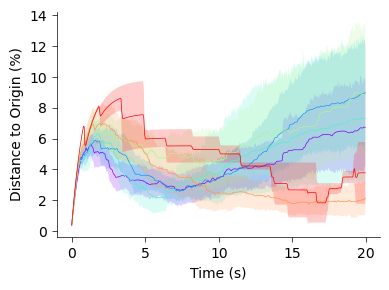

In [13]:
subset = SubDict(TrialBinnedData, np.where(TrialBinnedData['Trial Type'] == "Successful")[0])
fig = plt.figure(figsize=(4, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x=subset["Time"],
    y=subset["Dist"],
    hue=subset["Trial Block"],
    palette='rainbow',
    linewidth=0.5,
    err_kws={"edgecolor":None},
    legend=False
)
ax.set_ylabel("Distance to Origin (%)")
ax.set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig(join(loc_fish, "Distance to Origin By Trial Block.png"), dpi=600)
plt.savefig(join(loc_fish, "Distance to Origin By Trial Block.svg"), dpi=600)
plt.show()

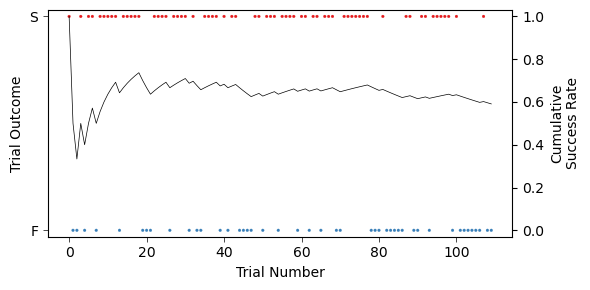

In [18]:
fig = plt.figure(figsize=(6, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
beg = np.where(np.diff(TrialBinnedData['Trial']) != 0)[0] + 1
beg = np.concatenate(([0], beg))
sns.scatterplot(
    x=TrialBinnedData["Trial"][beg],
    y=np.where(TrialBinnedData["Trial Type"][beg] == "Successful", 1, 0),
    hue=TrialBinnedData["Trial Type"][beg],
    palette='Set1',
    s=4,
    edgecolor=None,
    legend=False,
    ax=ax
)
ax.set_yticks([0, 1], labels=["F", "S"])
ax.set_ylabel("Trial Outcome")
ratio = np.cumsum(np.where(TrialBinnedData["Trial Type"][beg] == "Successful", 1, 0)) / np.arange(1, len(beg) + 1)
axt = ax.twinx()
axt.plot(TrialBinnedData["Trial"][beg], ratio, color='k', lw=0.5)
axt.set_ylabel("Cumulative\nSuccess Rate")
axt.set_ylim(-0.03, 1.03)
ax.set_ylim(-0.03, 1.03)
ax.set_xlabel("Trial Number")
plt.tight_layout()
plt.savefig(join(loc_fish, "Trial Outcome.png"), dpi=600)
plt.savefig(join(loc_fish, "Trial Outcome.svg"), dpi=600)
plt.show()

<Axes: >

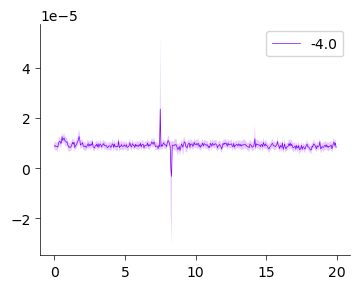

In [ ]:
plt.hist(TrialBinned)
fig = plt.figure(figsize=(4, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
TrialBinnedData['Angle Binned'] = np.ones(len(TrialBinnedData['Time']))-5
TrialBinnedData['Angle Binned'][np.where((TrialBinnedData['Displacement Angle'] >= np.pi / 3 * 2)&(TrialBinnedData['Displacement Angle'] < np.pi / 6 * 5))[0]] = 2
TrialBinnedData['Angle Binned'][np.where((TrialBinnedData['Displacement Angle'] >= np.pi / 6 * 5)&(TrialBinnedData['Displacement Angle'] < np.pi))[0]] = 1
TrialBinnedData['Angle Binned'][np.where((TrialBinnedData['Displacement Angle'] > -np.pi)&(TrialBinnedData['Displacement Angle'] <= -np.pi / 6 * 5))[0]] = -1
TrialBinnedData['Angle Binned'][np.where((TrialBinnedData['Displacement Angle'] > -np.pi / 6 * 5)&(TrialBinnedData['Displacement Angle'] <= -np.pi / 3 * 2))[0]] = -2

sns.lineplot(
    x=TrialBinnedData["Time"],
    y=TrialBinnedData["Power Diff"],
    hue=TrialBinnedData["Angle Binned"],
    palette='rainbow',
    linewidth=0.5,
    err_kws={"edgecolor":None}
)

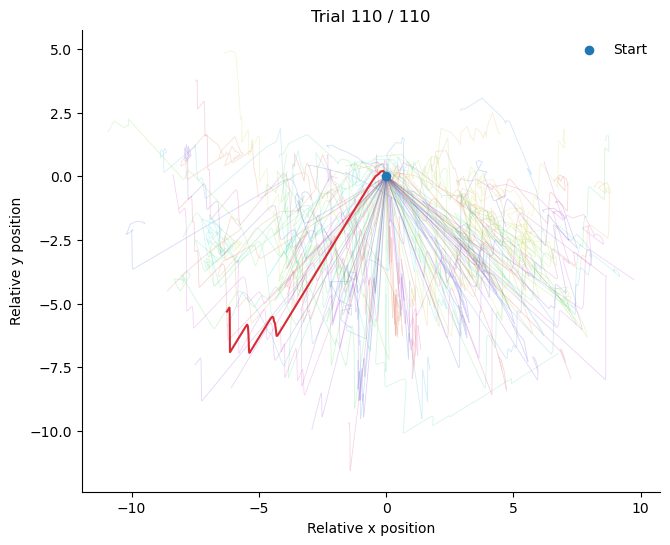

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import hsv_to_rgb


# ------------------------------------------------------------
# 1. Precompute the trajectory of every trial
# ------------------------------------------------------------
trajectories = []

for i in range(len(beg)):
    trial_slice = slice(beg[i], min(end[i], beg[i] + 30000))

    x, y = coordinate_orient(
        res["behav_pos_x"][trial_slice] - 50,
        res["behav_pos_y"][trial_slice] - 50,
        res["behav_orient"][beg[i]],
    )

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Express each trajectory relative to its starting position
    x = x - x[0]
    y = y - y[0]

    trajectories.append((x, y))


# ------------------------------------------------------------
# 2. Determine common axis limits
# ------------------------------------------------------------
all_x = np.concatenate([xy[0] for xy in trajectories])
all_y = np.concatenate([xy[1] for xy in trajectories])

x_margin = 0.05 * max(np.ptp(all_x), 1)
y_margin = 0.05 * max(np.ptp(all_y), 1)

x_limits = (np.nanmin(all_x) - x_margin, np.nanmax(all_x) + x_margin)
y_limits = (np.nanmin(all_y) - y_margin, np.nanmax(all_y) + y_margin)


# Generate rainbow-like colors without requiring seaborn
colors = [
    hsv_to_rgb((i / max(len(trajectories), 1), 0.8, 0.85))
    for i in range(len(trajectories))
]


# ------------------------------------------------------------
# 3. Set up the figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# You can replace this with your Clear_Axes function:
# ax = Clear_Axes(
#     plt.axes(),
#     close_spines=["top", "right"],
#     ifxticks=True,
#     ifyticks=True,
# )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Relative x position")
ax.set_ylabel("Relative y position")

title = ax.set_title("Trial 1")

# One line object per trial
lines = [
    ax.plot([], [], lw=0.8, color=colors[i])[0]
    for i in range(len(trajectories))
]

# Starting location
ax.scatter([0], [0], marker="o", s=35, label="Start", zorder=5)
ax.legend(frameon=False)


# ------------------------------------------------------------
# 4. Animation functions
# ------------------------------------------------------------
def init():
    for line in lines:
        line.set_data([], [])
    title.set_text("")
    return [*lines, title]


def update(trial_index):
    for i, line in enumerate(lines):
        if i < trial_index:
            # Previous trials remain visible but become faint
            line.set_data(*trajectories[i])
            line.set_alpha(0.20)
            line.set_linewidth(0.6)

        elif i == trial_index:
            # Current trial is emphasized
            line.set_data(*trajectories[i])
            line.set_alpha(1.0)
            line.set_linewidth(1.5)

        else:
            # Future trials are hidden
            line.set_data([], [])

    title.set_text(
        f"Trial {trial_index + 1} / {len(trajectories)}"
    )

    return [*lines, title]


animation = FuncAnimation(
    fig,
    update,
    frames=len(trajectories),
    init_func=init,
    interval=700,   # milliseconds per trial
    blit=True,
    repeat=True,
)

animation.save(
    join(loc_fish, "fish_trajectory_by_trial.mp4"),
    writer="ffmpeg",
    fps=2,
    dpi=200,
)

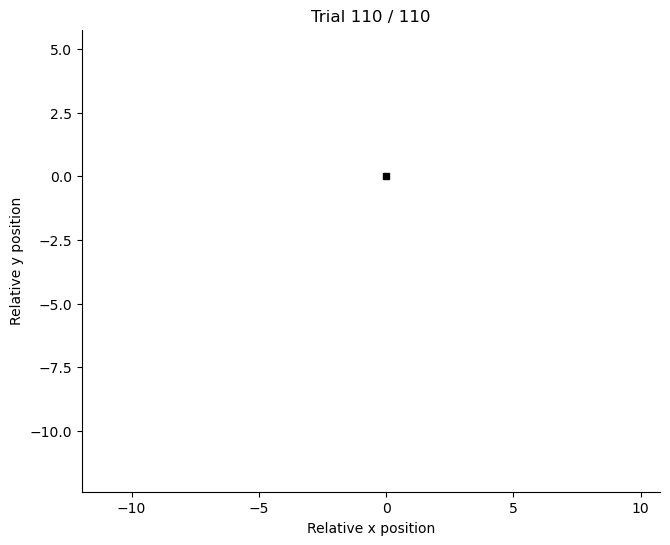

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ------------------------------------------------------------
# 1. Precompute trajectory for each trial
# ------------------------------------------------------------
trajectories = []

for i in range(len(beg)):
    trial_slice = slice(beg[i], min(end[i], beg[i] + 30000))

    x, y = coordinate_orient(
        res['behav_pos_x'][trial_slice] - 50,
        res['behav_pos_y'][trial_slice] - 50,
        res['behav_orient'][beg[i]]
    )

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # shift so each trial starts at (0,0)
    x = x - x[0]
    y = y - y[0]

    trajectories.append((x, y))


# ------------------------------------------------------------
# 2. Animation parameters
# ------------------------------------------------------------
sampling_rate = 6000          # Hz
fps = 10                      # animation frames per second
step = sampling_rate // fps   # 600 samples per frame

# number of animation frames in each trial
frames_per_trial = [
    int(np.ceil(len(x) / step))
    for x, y in trajectories
]

# cumulative frame index, so we can map global frame -> trial/frame
cum_frames = np.cumsum([0] + frames_per_trial)
total_frames = cum_frames[-1]


# ------------------------------------------------------------
# 3. Shared axis limits
# ------------------------------------------------------------
all_x = np.concatenate([x for x, y in trajectories])
all_y = np.concatenate([y for x, y in trajectories])

x_margin = 0.05 * max(np.ptp(all_x), 1)
y_margin = 0.05 * max(np.ptp(all_y), 1)

xlim = (np.nanmin(all_x) - x_margin, np.nanmax(all_x) + x_margin)
ylim = (np.nanmin(all_y) - y_margin, np.nanmax(all_y) + y_margin)


# ------------------------------------------------------------
# 4. Set up figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# If you want to use your Clear_Axes, replace the following styling block
# ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Relative x position')
ax.set_ylabel('Relative y position')

# line for full trajectory so far
history_line, = ax.plot([], [], lw=1.0)

# line for most recent chunk (last 600 points)
recent_line, = ax.plot([], [], lw=2.0)

# moving point
point, = ax.plot([], [], 'o', markersize=6)

# mark start point
ax.plot(0, 0, 'ks', markersize=5)

title = ax.set_title('')
time_text = ax.text(
    0.02, 0.98, '',
    transform=ax.transAxes,
    ha='left', va='top'
)


# ------------------------------------------------------------
# 5. Helper: map global frame index to (trial, local_frame)
# ------------------------------------------------------------
def get_trial_and_local_frame(global_frame):
    trial_idx = np.searchsorted(cum_frames[1:], global_frame, side='right')
    local_frame = global_frame - cum_frames[trial_idx]
    return trial_idx, local_frame


# ------------------------------------------------------------
# 6. Init function
# ------------------------------------------------------------
def init():
    history_line.set_data([], [])
    recent_line.set_data([], [])
    point.set_data([], [])
    title.set_text('')
    time_text.set_text('')
    return history_line, recent_line, point, title, time_text


# ------------------------------------------------------------
# 7. Update function
# ------------------------------------------------------------
def update(global_frame):
    trial_idx, local_frame = get_trial_and_local_frame(global_frame)
    x, y = trajectories[trial_idx]

    # current sample index
    end_idx = min((local_frame + 1) * step, len(x))

    # full path so far
    x_hist = x[:end_idx]
    y_hist = y[:end_idx]

    # recent segment: last 600 points
    start_recent = max(0, end_idx - step)
    x_recent = x[start_recent:end_idx]
    y_recent = y[start_recent:end_idx]

    # current point
    x_now = x[end_idx - 1]
    y_now = y[end_idx - 1]

    history_line.set_data(x_hist, y_hist)
    recent_line.set_data(x_recent, y_recent)
    point.set_data([x_now], [y_now])

    title.set_text(f'Trial {trial_idx + 1} / {len(trajectories)}')
    time_text.set_text(
        f't = {end_idx / sampling_rate:.2f} s\n'
        f'sample = {end_idx} / {len(x)}'
    )

    return history_line, recent_line, point, title, time_text


# ------------------------------------------------------------
# 8. Create animation
# ------------------------------------------------------------
anim = FuncAnimation(
    fig,
    update,
    frames=total_frames,
    init_func=init,
    interval=100,   # 100 ms per frame = 10 fps
    blit=True,
    repeat=True
)

anim.save(
    join(loc_fish, "fish_trajectory_by_moment.mp4"),
    writer="ffmpeg",
    fps=2,
    dpi=200,
)

# OF LED

In [ ]:
path_led = r"D:\EnData\Open Field\10232\S1-OF-LED+Displacement\res.16chFlt"
fish = 10232
fish_loc = os.path.join(loc, str(fish))
os.makedirs(fish_loc, exist_ok=True)

res = import16chFlt(path_led, nchannel=28)
idx = np.where((res['behav_time'] > 5) & (res['behav_pos_x'] <= 100) & (res['behav_pos_y'] <= 100))[0]
for k in res.keys():
    res[k] = res[k][idx]

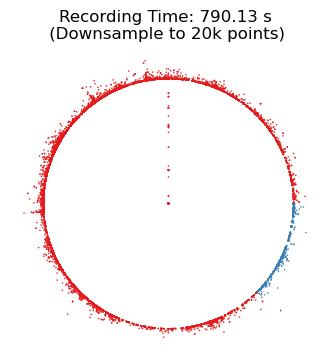

In [4]:
opt_state = res['opto_states'].astype(np.int64)
rand_idx = np.random.choice(len(opt_state), size=20000, replace=False)

fig = plt.figure(figsize=(4, 4))
ax = Clear_Axes(plt.axes())
sns.scatterplot(
    x=res['behav_pos_x'][rand_idx] - 50, 
    y=res['behav_pos_y'][rand_idx] - 50, 
    hue=opt_state[rand_idx], 
    palette='Set1', 
    s=1, 
    edgecolor=None,
    legend=False
)
ax.set_aspect('equal', adjustable='box')
ax.set_title(f"Recording Time: {res['behav_time'][-1]:.2f} s\n (Downsample to 20k points)")
plt.savefig(join(fish_loc, "LED State vs. Trajectory.png"), dpi=600)
plt.savefig(join(fish_loc, "LED State vs. Trajectory.svg"), dpi=300)
plt.show()

In [4]:
led_turn_on = np.where(np.diff(opt_state) > 0)[0] + 1
led_turn_on = led_turn_on[1:] # Remove the first LED turn-on event to avoid edge effects
led_turn_off = np.where(np.diff(opt_state) < 0)[0] + 1

ch0 = np.convolve(res['fltCh0'], np.ones(200), mode='same') / np.convolve(np.ones(res['fltCh0'].shape[0]), np.ones(200), mode='same')  # moving average with window size 200
ch1 = np.convolve(res['fltCh1'], np.ones(200), mode='same') / np.convolve(np.ones(res['fltCh1'].shape[0]), np.ones(200), mode='same')  # moving average with window size 200

def rereference_data(x, y, theta):
    alpha = np.arctan2(y, x) % (2 * np.pi)
    radial = np.sqrt(x**2 + y**2)
    return alpha - alpha[0], radial - radial[0]

Processing LED turn-on events:   0%|          | 0/239 [00:00<?, ?it/s]

Processing LED turn-on events: 100%|██████████| 239/239 [00:23<00:00, 10.24it/s]


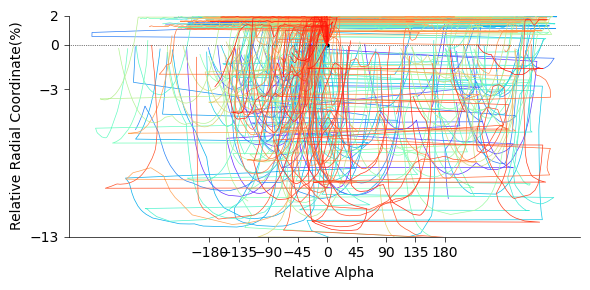

In [19]:
LEDOnData = {
    "Time": [],
    "SwimPower": [],
    "RelativeAlpha": [],
    "Radial": [],
    "Trial": []
}

fig = plt.figure(figsize=(6, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
colors = sns.color_palette("rainbow", len(led_turn_on))

for i in tqdm(range(len(led_turn_on)), desc="Processing LED turn-on events"):
    if i != len(led_turn_on) - 1:
        last_time = min(res['behav_time'][led_turn_on[i+1]-1], res['behav_time'][led_turn_on[i]] + 20)
    else:
        last_time = res['behav_time'][led_turn_on[i]] + 20
    trial_idx = np.where((res['behav_time'] >= res['behav_time'][led_turn_on[i]]) & (res['behav_time'] <= last_time))[0]
    t = ((res['behav_time'][trial_idx] - res['behav_time'][led_turn_on[i]]) // 0.05)*0.05
    alpha, radial = rereference_data(res['behav_pos_x'][trial_idx] - 50, res['behav_pos_y'][trial_idx] - 50, res['behav_orient'][trial_idx])
    ax.plot(np.rad2deg(alpha), radial, color=colors[i], lw=0.5)
    
    LEDOnData["Time"].append(t)
    LEDOnData["SwimPower"].append((ch0[trial_idx]+ch1[trial_idx])/2)
    LEDOnData["RelativeAlpha"].append(np.rad2deg(alpha))
    LEDOnData["Radial"].append(radial)
    LEDOnData["Trial"].append(np.full_like(t, i))  # Store trial index for each time point
    
ax.scatter([0], [0], marker='o', s=5, color='k', label='Start')
ax.set_xlabel("Relative Alpha")
ax.set_ylabel("Relative Radial Coordinate(%)")
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set_xticks(np.linspace(-180, 180, 9))
ax.set_ylim(-13, 2)
ax.set_yticks([-13, -3, 0, 2])
plt.tight_layout()
plt.savefig(join(fish_loc, "Radial vs. Relative Alpha.png"), dpi=600)
plt.savefig(join(fish_loc, "Radial vs. Relative Alpha.svg"), dpi=300)
plt.show()

for key in LEDOnData:
    LEDOnData[key] = np.concatenate(LEDOnData[key])

In [16]:
ProcessedTurnOnData = {
    "Time":[],
    "Medial Swim Power":[],
    "Medial Relative Alpha":[],
    "Medial Radial":[],
    "Trial":[]
}
time_binned = np.linspace(0, 20, 401)[:-1]
for i in tqdm(np.unique(LEDOnData["Trial"]), desc="Binning LED turn-on events"):
    trial_mask = np.where(LEDOnData["Trial"] == i)[0]
    swim_power_binned = np.zeros_like(time_binned)
    relative_alpha_binned = np.zeros_like(time_binned)
    radial_binned = np.zeros_like(time_binned)
    
    sp = LEDOnData["SwimPower"][trial_mask]
    ra = LEDOnData["RelativeAlpha"][trial_mask]
    rd = LEDOnData["Radial"][trial_mask]
    
    for j in range(len(time_binned)):
        t = LEDOnData["Time"][trial_mask]
        time_bin_mask = np.where((t >= time_binned[j]-1e-3) & (t < time_binned[j]+1e-3))[0]
        swim_power_binned[j] = np.median(sp[time_bin_mask])
        relative_alpha_binned[j] = np.median(ra[time_bin_mask])
        radial_binned[j] = np.median(rd[time_bin_mask])
        
    ProcessedTurnOnData["Time"].append(time_binned)
    ProcessedTurnOnData["Medial Swim Power"].append(swim_power_binned)
    ProcessedTurnOnData["Medial Relative Alpha"].append(relative_alpha_binned)
    ProcessedTurnOnData["Medial Radial"].append(radial_binned)
    ProcessedTurnOnData["Trial"].append(np.full_like(time_binned, i))
for key in ProcessedTurnOnData:
    ProcessedTurnOnData[key] = np.concatenate(ProcessedTurnOnData[key])

Binning LED turn-on events:   0%|          | 0/239 [00:00<?, ?it/s]d:\Software\Anaconda3\envs\maze\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
d:\Software\Anaconda3\envs\maze\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
Binning LED turn-on events: 100%|██████████| 239/239 [00:18<00:00, 12.66it/s]


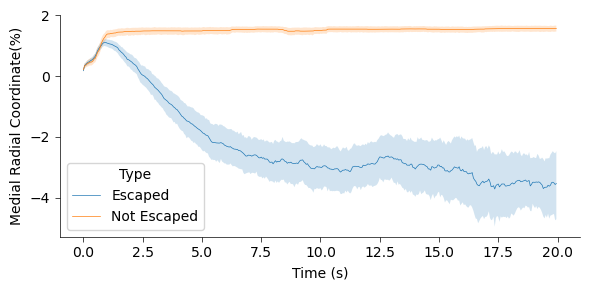

In [ ]:
ProcessedTurnOnData["Type"] = []
for trial in np.unique(ProcessedTurnOnData["Trial"]):
    trial_mask = np.where(ProcessedTurnOnData["Trial"] == trial)[0]
    is_escaped = np.where(ProcessedTurnOnData["Medial Radial"][trial_mask] < 0)[0].shape[0] > 0
    if is_escaped:
        ProcessedTurnOnData["Type"].extend(["Escaped"] * len(trial_mask))
    else:
        ProcessedTurnOnData["Type"].extend(["Not Escaped"] * len(trial_mask))
ProcessedTurnOnData["Type"] = np.array(ProcessedTurnOnData["Type"])

fig = plt.figure(figsize=(6, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x="Time",
    y="Medial Radial",
    data=ProcessedTurnOnData,
    hue="Type",
    linewidth=0.5,
    err_kws={'edgecolor':None}
)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Medial Radial Coordinate(%)")
plt.tight_layout()
plt.savefig(join(fish_loc, "Escape Radial Curve.png"), dpi=600)
plt.savefig(join(fish_loc, "Escape Radial Curve.svg"), dpi=300)
plt.show()

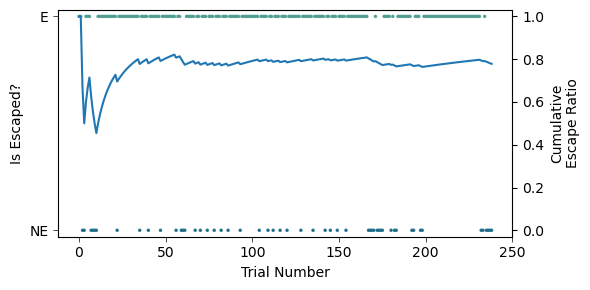

In [45]:
# Learning Effect?
fig = plt.figure(figsize=(6, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
trial_beg_idx = np.concatenate([[0], np.where(np.diff(ProcessedTurnOnData["Trial"]) > 0)[0] + 1])


ratio = np.cumsum(np.where(ProcessedTurnOnData["Type"]=='Escaped', 1, 0)[trial_beg_idx]) / np.arange(1, len(trial_beg_idx)+1)
sns.scatterplot(
    x=ProcessedTurnOnData["Trial"][trial_beg_idx],
    y=np.where(ProcessedTurnOnData["Type"][trial_beg_idx]=='Escaped', 1, 0),
    hue=ProcessedTurnOnData["Type"][trial_beg_idx],
    palette='crest',
    edgecolor=None,
    s=5,
    legend=False
)
axt = ax.twinx()
axt.plot(
    ProcessedTurnOnData["Trial"][trial_beg_idx], 
    ratio
)
ax.set_ylim(-0.03, 1.03)
axt.set_ylim(-0.03, 1.03)
axt.set_yticks(np.linspace(0, 1, 6))
axt.set_ylabel("Cumulative\nEscape Ratio")
ax.set_yticks([0, 1], labels=['NE', 'E'])
ax.set_xlabel("Trial Number")
ax.set_xticks(np.linspace(0, 250, 6).astype(np.int64))
ax.set_ylabel("Is Escaped?")
plt.tight_layout()
plt.savefig(join(fish_loc, "Escape Ratio.png"), dpi=600)
plt.savefig(join(fish_loc, "Escape Ratio.svg"), dpi=300)

# Swirl Induction

In [ ]:
swirl_path = r"D:\EnData\Open Field\10225\OF-Swirl\res.16chFlt"
res_swirl = import16chFlt(swirl_path, nchannel=25)
fish_loc_swirl = os.path.join(loc, str(fish), "Swirl")
os.makedirs(fish_loc_swirl, exist_ok=True)

idx = np.where((res_swirl['behav_time'] > 5) & (res_swirl['behav_pos_x'] <= 100) & (res_swirl['behav_pos_y'] <= 100))[0]
for k in res_swirl.keys():
    res_swirl[k] = res_swirl[k][idx]

Plotting Swirl Trajectories: 100%|██████████| 124/124 [00:00<00:00, 262.04it/s]


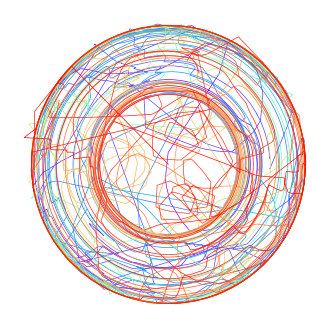

In [ ]:
swirl_beg = np.where(np.diff(res_swirl['n_swirls']) > 0)[0][1:] + 1
swirl_end = np.append(swirl_beg[1:], len(res_swirl['n_swirls']))

fig = plt.figure(figsize=(4, 4))
colors = sns.color_palette("rainbow", len(swirl_beg))
ax = Clear_Axes(plt.axes())
for i in tqdm(range(len(swirl_beg)), desc="Plotting Swirl Trajectories"):
    x = res_swirl['behav_pos_x'][swirl_beg[i]:swirl_end[i]] - 50
    y = res_swirl['behav_pos_y'][swirl_beg[i]:swirl_end[i]] - 50
    ax.plot(x, y, color=colors[i], lw=0.5)
ax.set_title(f"Recording Time: {res_swirl['behav_time'][-1]:.2f} s\n({np.max(res_swirl['n_swirls'])} Swirls)")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import hsv_to_rgb

# ------------------------------------------------------------
# 1. Precompute trajectories
# ------------------------------------------------------------
trajectories = []

for i in range(len(swirl_beg)):
    x = np.asarray(res_swirl['behav_pos_x'][swirl_beg[i]:swirl_end[i]], dtype=float) - 50
    y = np.asarray(res_swirl['behav_pos_y'][swirl_beg[i]:swirl_end[i]], dtype=float) - 50
    trajectories.append((x, y))

# ------------------------------------------------------------
# 2. Animation parameters
# ------------------------------------------------------------
sampling_rate = 6000   # Hz
fps = 10               # movie frames per second
step = sampling_rate // fps   # 600 samples per frame

frames_per_trial = [
    int(np.ceil(len(x) / step))
    for x, y in trajectories
]

cum_frames = np.cumsum([0] + frames_per_trial)
total_frames = cum_frames[-1]

# ------------------------------------------------------------
# 3. Axis limits
# ------------------------------------------------------------
all_x = np.concatenate([x for x, y in trajectories])
all_y = np.concatenate([y for x, y in trajectories])

x_margin = 0.05 * max(np.ptp(all_x), 1)
y_margin = 0.05 * max(np.ptp(all_y), 1)

xlim = (np.nanmin(all_x) - x_margin, np.nanmax(all_x) + x_margin)
ylim = (np.nanmin(all_y) - y_margin, np.nanmax(all_y) + y_margin)

# ------------------------------------------------------------
# 4. Colors
# ------------------------------------------------------------
colors = [
    hsv_to_rgb((i / max(len(trajectories), 1), 0.85, 0.9))
    for i in range(len(trajectories))
]

# ------------------------------------------------------------
# 5. Figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(4, 4))
ax = Clear_Axes(plt.axes())

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_aspect('equal', adjustable='box')

# one faint line per finished trial
background_lines = [
    ax.plot([], [], color=colors[i], lw=0.6, alpha=0.15)[0]
    for i in range(len(trajectories))
]

# current-trial history
history_line, = ax.plot([], [], lw=1.2)

# last 600 points
recent_line, = ax.plot([], [], lw=2.0)

# current position
point, = ax.plot([], [], 'o', markersize=5)

title = ax.set_title('')
time_text = ax.text(
    0.02, 0.98, '',
    transform=ax.transAxes,
    ha='left', va='top'
)

# ------------------------------------------------------------
# 6. Helper
# ------------------------------------------------------------
def get_trial_and_local_frame(global_frame):
    trial_idx = np.searchsorted(cum_frames[1:], global_frame, side='right')
    local_frame = global_frame - cum_frames[trial_idx]
    return trial_idx, local_frame

# ------------------------------------------------------------
# 7. Init
# ------------------------------------------------------------
def init():
    for line in background_lines:
        line.set_data([], [])
    history_line.set_data([], [])
    recent_line.set_data([], [])
    point.set_data([], [])
    title.set_text('')
    time_text.set_text('')
    return [*background_lines, history_line, recent_line, point, title, time_text]

# ------------------------------------------------------------
# 8. Update
# ------------------------------------------------------------
def update(global_frame):
    trial_idx, local_frame = get_trial_and_local_frame(global_frame)

    x, y = trajectories[trial_idx]
    color = colors[trial_idx]

    end_idx = min((local_frame + 1) * step, len(x))
    start_recent = max(0, end_idx - step)

    # show completed trials faintly
    for i, line in enumerate(background_lines):
        if i < trial_idx:
            line.set_data(*trajectories[i])
            line.set_alpha(0.15)
        else:
            line.set_data([], [])

    # current trial
    x_hist = x[:end_idx]
    y_hist = y[:end_idx]

    x_recent = x[start_recent:end_idx]
    y_recent = y[start_recent:end_idx]

    history_line.set_data(x_hist, y_hist)
    history_line.set_color(color)

    recent_line.set_data(x_recent, y_recent)
    recent_line.set_color(color)

    point.set_data([x[end_idx - 1]], [y[end_idx - 1]])
    point.set_color(color)

    title.set_text(f'Swirl trial {trial_idx + 1} / {len(trajectories)}')
    time_text.set_text(
        f't = {end_idx / sampling_rate:.2f} s\n'
        f'sample = {end_idx} / {len(x)}'
    )

    return [*background_lines, history_line, recent_line, point, title, time_text]

# ------------------------------------------------------------
# 9. Animation
# ------------------------------------------------------------
anim = FuncAnimation(
    fig,
    update,
    frames=total_frames,
    init_func=init,
    interval=100,   # 100 ms => 10 fps
    blit=True,
    repeat=True
)

anim.save(
    join(fish_loc_swirl, "swirl_trajectory_by_moment.mp4"),
    writer="ffmpeg",
    fps=5,
    dpi=200,
)